## Analysis Document

Import libraries

In [13]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Load the CVIS

In [14]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
RANDOM_STATE = 42

DATA_DIR = Path.cwd()
CSVI_DATA_PATH =  DATA_DIR /"csvi_data.json"
CSVI_CVES_PATH =  DATA_DIR /"csvi_cves.json"

with open(CSVI_DATA_PATH, "r") as f:
    csvi_data = json.load(f)

with open(CSVI_CVES_PATH, "r") as f:
    csvi_cves = json.load(f)

cves = pd.DataFrame(csvi_cves)

print("Organisations:", sum(len(v) for v in csvi_data.values()))
display(cves.describe(include= "all"))

Organisations: 50


,cve,cvss,epss,kev,attack_vector,attack_complexity,patch_available
count,122,122.000000,122.000000,122.0,122,122,122
unique,122,NaN,NaN,3.0,5,2,3
top,CVE-2025-69123,NaN,NaN,0.0,N,L,Y
freq,1,NaN,NaN,65.0,105,85,78
mean,NaN,6.269672,0.351426,NaN,NaN,NaN,NaN
std,NaN,2.152795,0.289254,NaN,NaN,NaN,NaN
min,NaN,1.100000,0.011000,NaN,NaN,NaN,NaN
25%,NaN,4.725000,0.097000,NaN,NaN,NaN,NaN
50%,NaN,6.000000,0.255500,NaN,NaN,NaN,NaN
75%,NaN,7.575000,0.551500,NaN,NaN,NaN,NaN


Normilise and clean

In [15]:
def normilise_attack_vector(vector):
    mapping = {
        "N": "Network",
        "NETWORK": "Network",
        "A": "Adjacent",
        "L": "Local",
        "P": "Physical"
    }
    if pd.isna(vector):
        return np.nan
    
    stripped_vector = str(vector).strip()
    return mapping.get(stripped_vector.upper(),stripped_vector)

def normalise_patch_available(patch):
    if pd.isna(patch):
        return "Unknown"
    patch_str = str(patch).strip().lower()

    if patch_str in ["yes","y", "true", "t"]:
        return "y"
    elif patch_str in ["no", "n", "false", "f"]:
        return "n"
    else:
        return "Unknown"
    
def normalise_kev(kev):
    if pd.isna(kev):
        return 0
    kev_str = str(kev).strip().lower()

    if kev_str in ["yes","y", "true", "t", "1"]:
        return 1
    if kev_str in ["no", "n", "false", "f", "0","none"]:
        return 0
    try:
        return int(float(kev_str))
    except Exception:
        return 0
    
# Clean and normalise the CVE data
cves_clean = cves.copy()
cves_clean["cve"] = cves_clean["cve"].astype(str).str.strip()
cves_clean["cvss"] = pd.to_numeric(cves_clean["cvss"], errors= "coerce")
cves_clean["epss"] = pd.to_numeric(cves_clean["epss"], errors= "coerce")

# CVSS 0-10
bad_cvss = cves_clean["cvss"].notna() & ~ cves_clean["cvss"].between(0, 10)
cves_clean.loc[bad_cvss, "cvss"] = np.nan

# EPSS 0–1
bad_epss = cves_clean["epss"].notna() & ~ cves_clean["epss"].between(0, 1)
cves_clean.loc[bad_epss, "epss"] = np.nan

print("Bad CVSS:", int(bad_cvss.sum()))
print("Bad EPSS:", int(bad_epss.sum()))
display(cves_clean.loc[bad_cvss,["cve", "cvss"]])

cves_clean["kev"] = cves_clean["kev"].apply(normalise_kev)
cves_clean["attack_vector"] = cves_clean["attack_vector"].apply(normilise_attack_vector)
cves_clean["attack_complexity"] = cves_clean["attack_complexity"].astype(str).str.strip().str.title()
cves_clean["patch_available"] = cves_clean["patch_available"].apply(normalise_patch_available)


# check for duplicates 
dupes = cves_clean["cve"].duplicated().sum()
print(f"Number of duplicate CVEs:{dupes}")

# Display cleaned data
display(cves_clean["attack_vector"].value_counts(dropna= False))
display(cves_clean["patch_available"].value_counts(dropna =False))
display(cves_clean[["cvss", "epss","kev"]].describe())

Bad CVSS: 1
Bad EPSS: 0


,cve,cvss
66,CVE-2024-12786,NaN


Number of duplicate CVEs:0


attack_vector
Network     106
Adjacent      7
Local         6
Physical      3
Name: count, dtype: int64

patch_available
y          78
n          43
Unknown     1
Name: count, dtype: int64

,cvss,epss,kev
count,121.000000,122.000000,122.000000
mean,6.182645,0.351426,0.459016
std,1.934282,0.289254,0.500372
min,1.100000,0.011000,0.000000
25%,4.700000,0.097000,0.000000
50%,6.000000,0.255500,0.000000
75%,7.500000,0.551500,1.000000
max,9.900000,0.999000,1.000000


Flatten data

In [16]:
CVE_REGEX = re.compile(r"^CVE-\d{4}-\d{4,}$" )

def clean_cve_id(raw):
    if raw is None:
        return None
    
    raw_str = str(raw).strip()
    raw_str = re.sub(r"\s+","", raw_str)
    return raw_str

rows = []
for sector, orgs in csvi_data.items():
    for org, cve_list in orgs.items():
        for cve in cve_list:
            cve_clean = clean_cve_id(cve)

            rows.append({
                "sector": str(sector).strip().title(),
                "organisation":str(org).strip(),
                "cve_raw": cve,
                "cve" : cve_clean,
                "cve_valid": bool(CVE_REGEX.match(cve_clean )) if cve_clean else False
            })

org_cves = pd.DataFrame(rows)

# Flag if not present in the CVE dataset
cve_set = set(cves_clean["cve"])
org_cves["in_cve_table"] = org_cves["cve"].isin(cve_set)

print("Rows (Org-cve):", len(org_cves))
print("Unique orgs: ", org_cves["organisation"].nunique())
print("invalid CVE strings:" , (~ org_cves["cve_valid"]).sum())
print("Valid but missing from CVE table:", ((org_cves["cve_valid"]) & (~org_cves["in_cve_table"])).sum())

# display the problematic CVE entries
display(org_cves.loc[(org_cves["cve_valid"]) & (~ org_cves["in_cve_table"]),["cve_raw","cve"]].drop_duplicates())

Rows (Org-cve): 655
Unique orgs:  50
invalid CVE strings: 0
Valid but missing from CVE table: 2


,cve_raw,cve
55,CVE-3022-71967,CVE-3022-71967
365,CVE-2022-12003,CVE-2022-12003


Join and Build analysis dataset 

In [17]:
data_long = org_cves.merge(cves_clean, on= "cve",how="left")

data_long["is_unpatched"] =data_long["patch_available"] == "n"
data_long["is_patched"] =data_long["patch_available"] == "y"


Exploratory Data Analysis

,sector,organisation,cve_count
35,Retail,Nova Fashion House,23
37,Retail,Summit Retail Group,23
38,Retail,Sunset Department Stores,22
39,Retail,The Outlet Co.,22
34,Retail,Harbor Home Goods,22
36,Retail,Redline Electronics,22
40,Retail,Urban Threads,22
33,Retail,Goldleaf Markets,22
31,Retail,BrightMart Stores,21
32,Retail,Everline Superstores,21


,sector,unique_cves
4,Retail,37
3,Manufacturing,33
5,Water,30
0,Airports,27
2,Finance,19
1,Energy,18


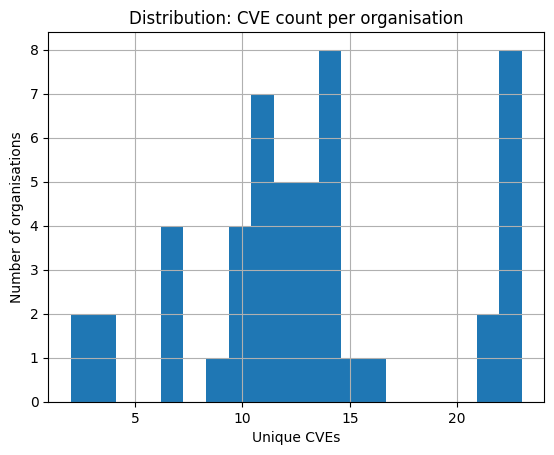

<Figure size 640x480 with 0 Axes>

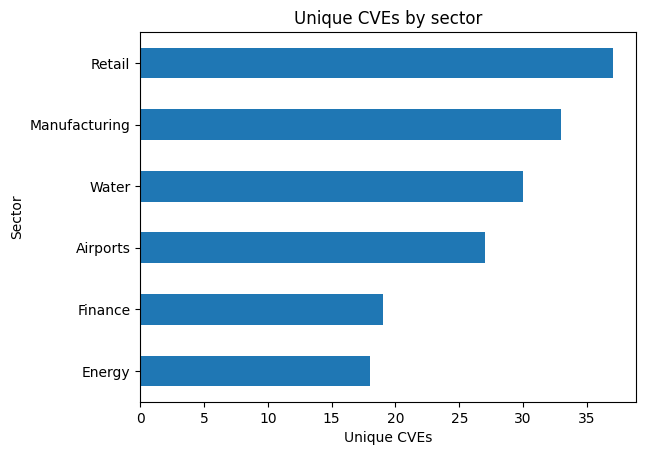

In [18]:
# basic counts 
org_counts = data_long.groupby(["sector","organisation"]) ["cve"].nunique().rename("cve_count").reset_index()
sector_counts = data_long.groupby("sector")["cve"].nunique().rename("unique_cves").reset_index()

display(org_counts.sort_values("cve_count", ascending= False).head(10))
display(sector_counts.sort_values("unique_cves", ascending =False))

plt.figure()
org_counts["cve_count"].hist(bins= 20)
plt.title("Distribution: CVE count per organisation")
plt.xlabel("Unique CVEs")
plt.ylabel("Number of organisations")
plt.show()

plt.figure()
sector_counts.sort_values("unique_cves", ascending= True).plot(kind= "barh", x= "sector", y="unique_cves",legend=False)
plt.title("Unique CVEs by sector")
plt.xlabel("Unique CVEs")
plt.ylabel("Sector")
plt.show()


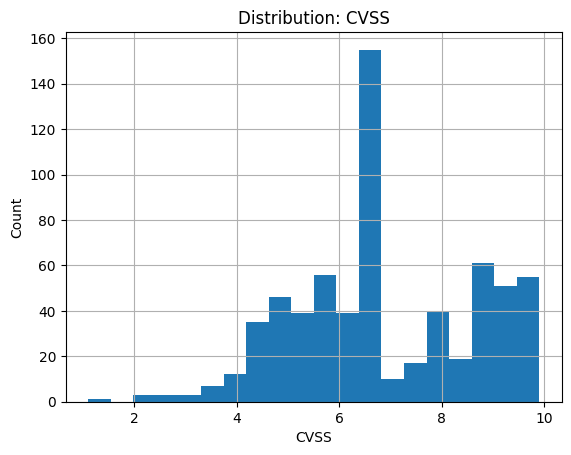

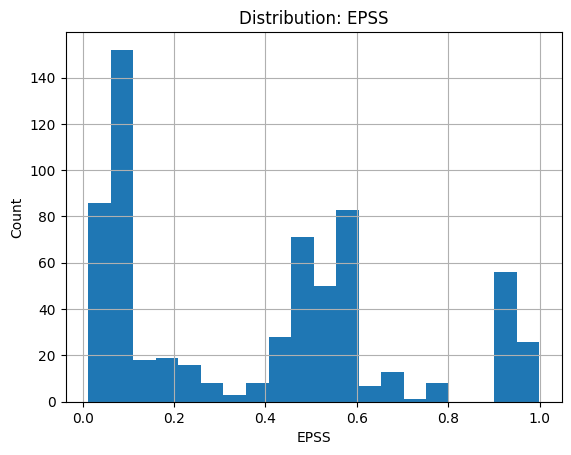

In [19]:
# Severity and likelihood distributions
plt.figure()
data_long["cvss"].dropna().hist(bins= 20)
plt.title("Distribution: CVSS")
plt.xlabel("CVSS")
plt.ylabel("Count")
plt.show()

plt.figure()
data_long["epss"].dropna().hist(bins= 20)
plt.title("Distribution: EPSS")
plt.xlabel("EPSS")
plt.ylabel("Count")
plt.show()


,sector,kev_rate
3,Manufacturing,0.877095
0,Airports,0.831461
5,Water,0.813187
1,Energy,0.590909
4,Retail,0.392694
2,Finance,0.056604


,sector,unpatched_rate
2,Finance,0.603774
1,Energy,0.545455
0,Airports,0.325843
4,Retail,0.245455
5,Water,0.076923
3,Manufacturing,0.050000


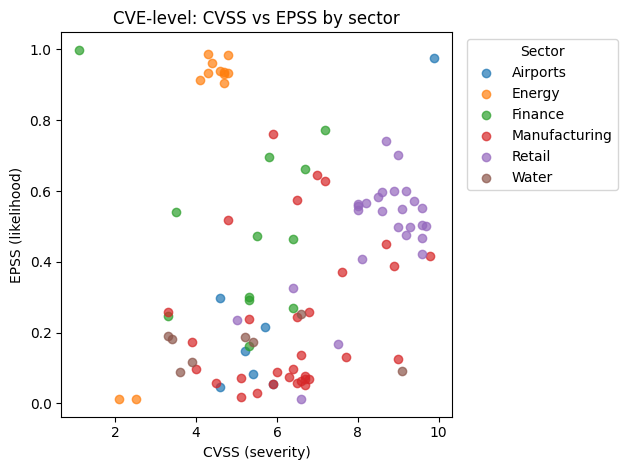

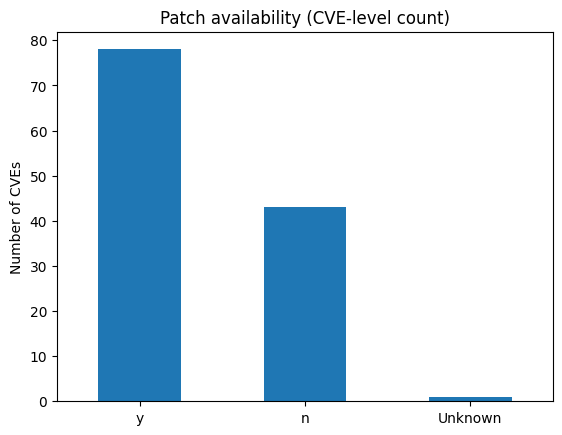

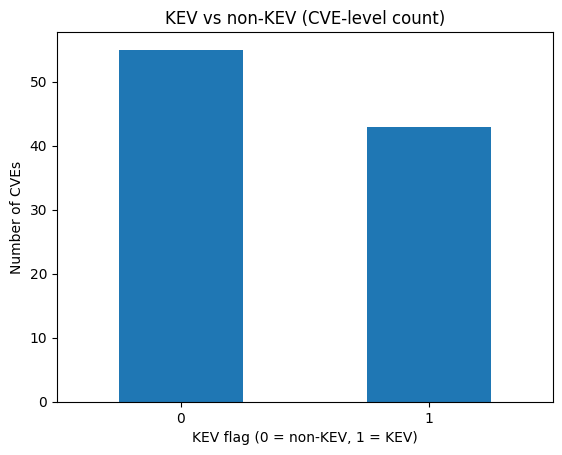

<Figure size 640x480 with 0 Axes>

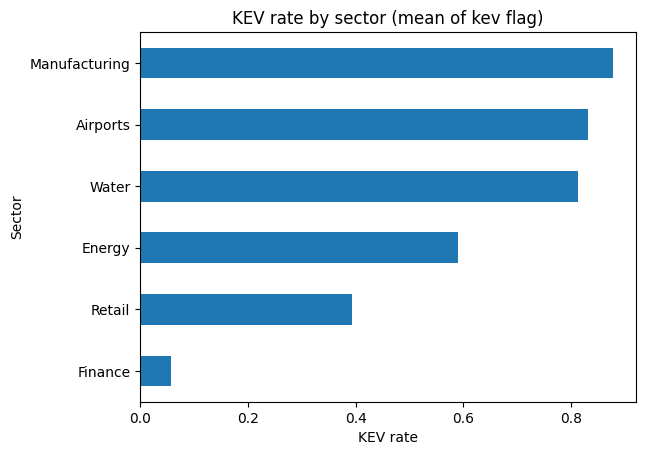

<Figure size 640x480 with 0 Axes>

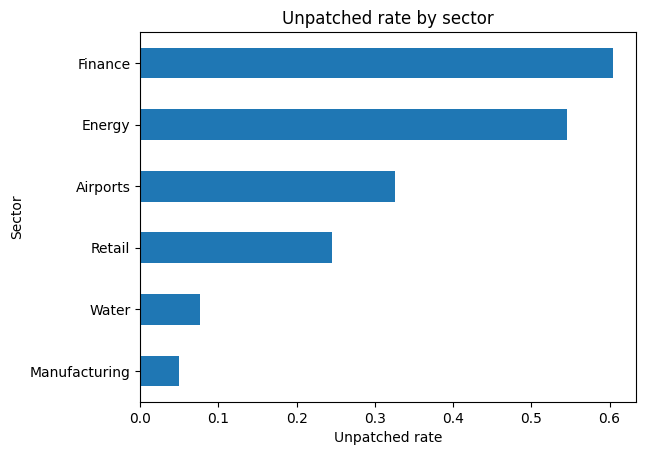

In [ ]:
# KEV and patching by sector
sector_kev = data_long.groupby("sector")["kev"].mean().rename("kev_rate").reset_index()
sector_patch = data_long.groupby("sector")["is_unpatched"].mean().rename("unpatched_rate").reset_index()

display(sector_kev.sort_values("kev_rate", ascending= False))
display(sector_patch.sort_values("unpatched_rate", ascending= False))

kev_counts = (data_long.drop_duplicates(subset=["cve"])["kev"].value_counts().reindex([0,1], fill_value= 0))

patch_counts = cves_clean["patch_available"].value_counts().reindex(["y","n","Unknown"], fill_value= 0)

sample = (data_long.dropna(subset= ["cvss", "epss", "sector"]).drop_duplicates(subset= ["cve"]))

plt.figure()
for sector, g in sample.groupby("sector"):
    plt.scatter(g["cvss"], g["epss"], alpha= 0.7, label= sector)

plt.title("CVE-level: CVSS vs EPSS by sector")
plt.xlabel("CVSS (severity)")
plt.ylabel("EPSS (likelihood)")
plt.legend(title= "Sector", bbox_to_anchor= (1.02, 1),loc= "upper left")
plt.tight_layout()
plt.show()

plt.figure()
patch_counts.plot(kind= "bar", legend= False)
plt.title("Patch availability (CVE-level count)")
plt.xlabel("")
plt.ylabel("Number of CVEs")
plt.xticks(rotation= 0)
plt.show()

plt.figure()
kev_counts.plot(kind= "bar", legend= False)
plt.title("KEV vs non-KEV (CVE-level count)")
plt.xlabel("KEV flag (0 = non-KEV, 1 = KEV)")
plt.ylabel("Number of CVEs")
plt.xticks(rotation= 0)
plt.show()

plt.figure()
sector_kev.sort_values("kev_rate", ascending= True).plot(kind= "barh", x= "sector",y ="kev_rate", legend=False)
plt.title("KEV rate by sector (mean of kev flag)")
plt.xlabel("KEV rate")
plt.ylabel("Sector")
plt.show()

plt.figure()
sector_patch.sort_values("unpatched_rate", ascending= True).plot(kind= "barh", x= "sector",y ="unpatched_rate", legend=False)
plt.title("Unpatched rate by sector")
plt.xlabel("Unpatched rate")
plt.ylabel("Sector")
plt.show()


Definition of at risk criteria and computing risk scores

In [25]:
# Normalise
data_long["cvss_norm"] = data_long["cvss"] /10.0
data_long["epss_norm"] = data_long["epss"]

# Priority per finding
data_long["priority"] = 0.5*data_long["cvss_norm"].fillna(0) + 0.5*data_long["epss_norm"].fillna(0)

data_long["patch_available"] = data_long["patch_available"].fillna("Unknown").astype(str).str.strip().str.lower()
data_long.loc[~ data_long["patch_available"].isin(["y","n"]),"patch_available"] = "Unknown"

data_long["patch_known"] = data_long["patch_available"].isin(["y","n"])
data_long["is_unpatched"] = data_long["patch_available"].eq("n")


# Aggregate per org
org_risk = data_long.groupby(["sector", "organisation"]).agg(
    cve_count= ("cve", "nunique"),
    mean_priority= ("priority", "mean"),
    sum_priority= ("priority", "sum"),
    kev_count= ("kev" ,"sum"),
    known_patch_coverage= ("patch_known", "mean"),
    unpatched_known_rate= ("is_unpatched",lambda s:s[data_long.loc[s.index, "patch_known"]].mean())

).reset_index()

# At risk definition top 5% of each key metric
p95_score = org_risk["sum_priority"].quantile(0.95)
p95_kev = org_risk["kev_count"].quantile(0.95)
# only compute unpatched tail among orgs with decent patch visibility
eligible = org_risk["known_patch_coverage"] >= 0.5
p95_unpatched = org_risk.loc[eligible, "unpatched_known_rate"].quantile(0.95)

org_risk["risk_exposure"] = org_risk["sum_priority"] >= p95_score
org_risk["risk_exploited"] = org_risk["kev_count"] >= p95_kev
org_risk["risk_hygiene"] = eligible & (org_risk["unpatched_known_rate"] >= p95_unpatched)

org_risk["at_risk_any"] = org_risk[["risk_exposure", "risk_exploited", "risk_hygiene"]].any(axis= 1)

org_risk["reason"] = org_risk[["risk_exposure" ,"risk_exploited", "risk_hygiene"]].apply(
    lambda r:", ".join([k for k, v in r.items() if v]) if any(r) else "None", axis= 1
)

print("Orgs flagged at risk: ", int( org_risk["at_risk_any"].sum()), "out of",len(org_risk))

# Sector rolls
sector_risk = org_risk.groupby("sector").agg(
    orgs= ("organisation", "nunique"),
    at_risk_orgs =("at_risk_any" ,"sum"),
    mean_sum_priority= ("sum_priority", "mean"),
    p90_sum_priority= ("sum_priority",lambda s:s.quantile(0.9)),
    mean_unpatched_known_rate= ("unpatched_known_rate", "mean"),
    mean_patch_coverage= ("known_patch_coverage", "mean")
).reset_index()

sector_risk["at_risk_fraction"] = sector_risk["at_risk_orgs"] /sector_risk["orgs"]
display(sector_risk.sort_values("at_risk_fraction", ascending= False))

at_risk_top10 = (
    org_risk.sort_values(["at_risk_any", "sum_priority", "kev_count", "unpatched_known_rate"],ascending= [False, False, False, False ]).head(10).loc[:,["sector", "organisation", "cve_count", "sum_priority","mean_priority", "kev_count", "known_patch_coverage", "unpatched_known_rate", "reason", "at_risk_any"]]
)

display(at_risk_top10)


Orgs flagged at risk:  10 out of 50


,sector,orgs,at_risk_orgs,mean_sum_priority,p90_sum_priority,mean_unpatched_known_rate,mean_patch_coverage,at_risk_fraction
1,Energy,4,2,2.828000,5.82835,0.653409,1.000000,0.500000
4,Retail,10,3,15.198450,15.72130,0.246438,0.995238,0.300000
3,Manufacturing,14,3,4.744714,5.58210,0.050188,0.994898,0.214286
2,Finance,6,1,4.662583,5.48450,0.608730,1.000000,0.166667
0,Airports,7,1,8.271357,8.67320,0.327292,0.989796,0.142857
5,Water,9,0,3.753222,5.15190,0.108514,1.000000,0.000000


,sector,organisation,cve_count,sum_priority,mean_priority,kev_count,known_patch_coverage,unpatched_known_rate,reason,at_risk_any
37,Retail,Summit Retail Group,23,15.7645,0.685413,9.0,1.0,0.304348,risk_exposure,True
36,Retail,Redline Electronics,22,15.7165,0.714386,9.0,1.0,0.227273,risk_exposure,True
35,Retail,Nova Fashion House,23,15.5220,0.674870,10.0,1.0,0.217391,risk_exposure,True
0,Airports,Ashbourne Airport,13,8.6720,0.667077,13.0,1.0,0.307692,risk_exploited,True
30,Manufacturing,Titan Metalcraft,16,5.8910,0.368188,14.0,1.0,0.000000,risk_exploited,True
19,Manufacturing,Brightline Industrial,15,5.7315,0.382100,13.0,1.0,0.000000,risk_exploited,True
18,Manufacturing,BlueForge Industries,14,5.2085,0.372036,13.0,1.0,0.071429,risk_exploited,True
12,Finance,BlueRock Securities,7,3.6430,0.520429,0.0,1.0,0.714286,risk_hygiene,True
10,Energy,VoltStream Power,4,1.5580,0.389500,1.0,1.0,0.750000,risk_hygiene,True
7,Energy,Helios Energy Corp,3,0.6950,0.231667,0.0,1.0,1.000000,risk_hygiene,True


CVE Co-occurance heatmap 

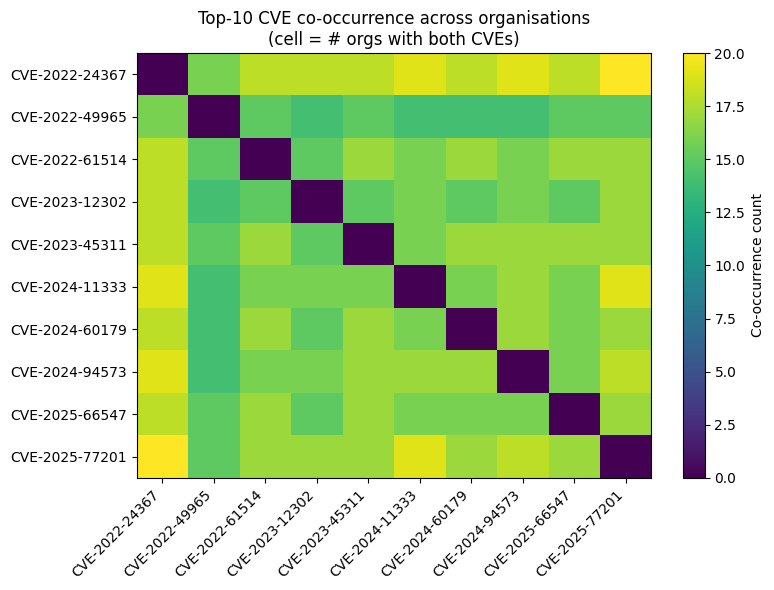

,cve_a,cve_b,org_count
0,CVE-2022-24367,CVE-2025-77201,20.0
1,CVE-2022-24367,CVE-2024-94573,19.0
2,CVE-2022-24367,CVE-2024-11333,19.0
3,CVE-2024-11333,CVE-2025-77201,19.0
4,CVE-2022-24367,CVE-2023-12302,18.0
5,CVE-2022-24367,CVE-2024-60179,18.0
6,CVE-2022-24367,CVE-2023-45311,18.0
7,CVE-2022-24367,CVE-2025-66547,18.0
8,CVE-2022-24367,CVE-2022-61514,18.0
9,CVE-2024-94573,CVE-2025-77201,18.0


,cve,orgs_affected
0,CVE-2022-24367,21
1,CVE-2025-77201,20
2,CVE-2023-45311,19
3,CVE-2022-61514,19
4,CVE-2024-11333,19
5,CVE-2024-94573,19
6,CVE-2025-66547,19
7,CVE-2024-60179,18
8,CVE-2023-12302,18
9,CVE-2022-49965,17


,cve,orgs_affected,patch_available
0,CVE-2022-24367,21,y
1,CVE-2025-77201,20,y
2,CVE-2023-45311,19,y
3,CVE-2022-61514,19,y
4,CVE-2024-11333,19,y
5,CVE-2024-94573,19,y
6,CVE-2025-66547,19,y
7,CVE-2024-60179,18,y
8,CVE-2023-12302,18,y
9,CVE-2022-49965,17,y


In [22]:
base = data_long[["sector",  "organisation","cve"]].dropna().copy()

# Unique Org–CVE pairs
base = base.drop_duplicates(subset= ["sector","organisation","cve"])

# Pick Top 10 CVEs by how many organisations they appear in
N = 10
top_cves = (
    base.groupby("cve")["organisation"].nunique().sort_values(ascending =False).head(N).index)

base_top = base[base["cve"].isin(top_cves)].copy()

# org x CVE binary matrix
org_ids = base_top["sector"].astype(str) +" | "+ base_top["organisation"].astype(str)
mat = pd.crosstab(org_ids,base_top["cve"]).astype(int)

# how many orgs contain both CVEs
co = mat.T @ mat
# ignore diagonal
np.fill_diagonal(co.values,0)

# Plot heatmap
plt.figure(figsize= (8,6))
plt.imshow(co.values, aspect="auto")
plt.title("Top-10 CVE co-occurrence across organisations\n(cell = # orgs with both CVEs)" )
plt.xticks(range(len(co.columns)),co.columns, rotation =45, ha= "right")
plt.yticks(range(len(co.index)),co.index)
plt.colorbar(label= "Co-occurrence count")
plt.tight_layout()
plt.show()

pairs = ( co.where(np.triu(np.ones(co.shape), k= 1).astype(bool)).stack() )

pairs.index = pairs.index.set_names(["cve_a", "cve_b"])

pairs = (pairs.sort_values(ascending= False).head(10).reset_index(name= "org_count"))

display(pairs)
top10_counts = base.groupby("cve")["organisation"].nunique().sort_values(ascending= False).head(10)
display(top10_counts.reset_index(name= "orgs_affected"))

top10_cves_patch = (
    top10_counts.reset_index(name= "orgs_affected")
        .merge(cves_clean[["cve", "patch_available"]], on= "cve", how= "left")
        .fillna({"patch_available":"Unknown"})
        .loc[:,["cve","orgs_affected", "patch_available"]]
)

display(top10_cves_patch)

Clustering with K-Means

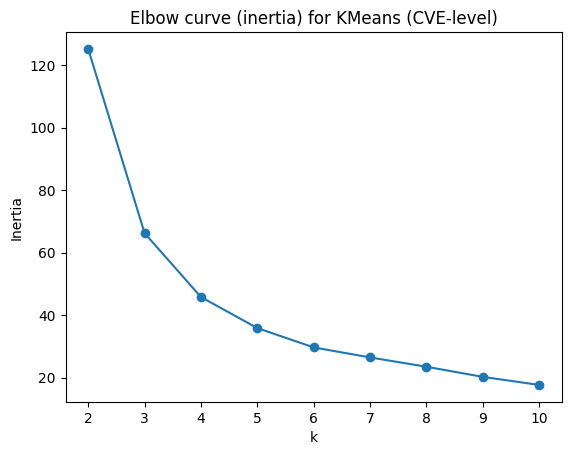

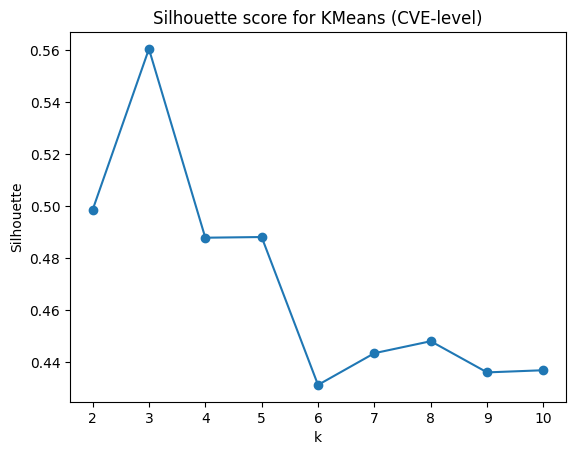

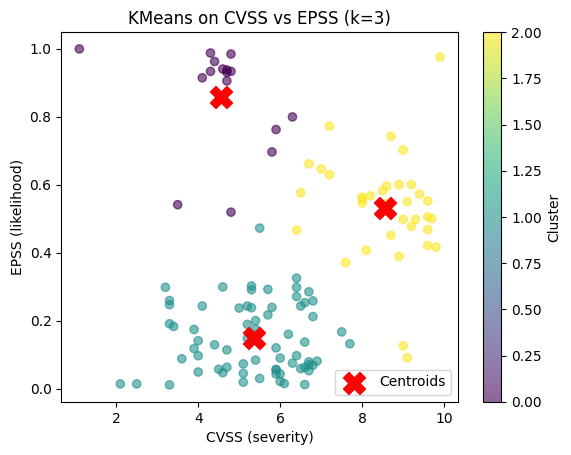

High-high cluster id: 2


,cvss_centroid,epss_centroid,cluster
0,4.550000,0.858812,0
1,5.362857,0.147629,1
2,8.568571,0.531943,2


,cve,cvss,epss,priority
108,CVE-2025-12121,9.9,0.975,0.9825
12,CVE-2021-60060,8.7,0.742,0.8060
42,CVE-2021-98323,9.0,0.702,0.8010
41,CVE-2022-76179,9.2,0.600,0.7600
65,CVE-2022-55432,9.6,0.552,0.7560
88,CVE-2022-34595,9.4,0.572,0.7560
120,CVE-2023-91568,7.2,0.772,0.7460
5,CVE-2023-66868,8.9,0.600,0.7450
76,CVE-2024-71326,9.7,0.500,0.7350
62,CVE-2025-55523,9.6,0.505,0.7325


,cve,cvss,epss,priority,patch_available
0,CVE-2025-12121,9.9,0.975,0.9825,n
1,CVE-2021-60060,8.7,0.742,0.8060,y
2,CVE-2021-98323,9.0,0.702,0.8010,y
3,CVE-2022-76179,9.2,0.600,0.7600,y
4,CVE-2022-55432,9.6,0.552,0.7560,y
5,CVE-2022-34595,9.4,0.572,0.7560,y
6,CVE-2023-91568,7.2,0.772,0.7460,n
7,CVE-2023-66868,8.9,0.600,0.7450,n
8,CVE-2024-71326,9.7,0.500,0.7350,n
9,CVE-2025-55523,9.6,0.505,0.7325,y


In [ ]:

org_risk["kev_rate"] =org_risk["kev_count"] /org_risk["cve_count"].replace(0,np.nan)
cve_level = (cves_clean[["cve","cvss", "epss"]].dropna(subset= ["cvss","epss"]).drop_duplicates(subset= ["cve"]).copy())

features = cve_level[["cvss", "epss"]].copy()

# Scale
scaler = StandardScaler()
X =scaler.fit_transform(features)

# Choose k via silhouette and inertia
ks = range(2, 11)
inertias, silhouettes = [],[]

for k in ks:
    km = KMeans(n_clusters= k, random_state= RANDOM_STATE, n_init= 20)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

plt.figure()
plt.plot(list(ks), inertias,marker= "o")
plt.title("Elbow curve (inertia) for KMeans (CVE-level)")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

plt.figure()
plt.plot(list(ks), silhouettes,marker="o")
plt.title("Silhouette score for KMeans (CVE-level)")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.show()

BEST_K = list(ks)[int(np.argmax(silhouettes))]

# fit final model and label CVES
km = KMeans(n_clusters= BEST_K, random_state= RANDOM_STATE, n_init=20)
cve_level["cluster"] = km.fit_predict(X)

plt.figure()
sc = plt.scatter(cve_level["cvss"],cve_level["epss"], c= cve_level["cluster"],alpha= 0.6)

centroids = scaler.inverse_transform(km.cluster_centers_)
plt.scatter(centroids[:,0], centroids[:, 1], s= 250, marker= "X", c="red", label= "Centroids")

plt.title(f"KMeans on CVSS vs EPSS (k={BEST_K})")
plt.xlabel("CVSS (severity)")
plt.ylabel("EPSS (likelihood)")
plt.legend()
plt.colorbar(sc, label= "Cluster")
plt.show()

centroids_df = pd.DataFrame(centroids,columns= ["cvss_centroid", "epss_centroid"]).assign(cluster= range(BEST_K))
high_high_cluster = int((centroids_df["cvss_centroid"] + centroids_df["epss_centroid"]).idxmax())

print("High-high cluster id:", high_high_cluster)
display(centroids_df)

top10 = (
    cve_level[cve_level["cluster"] == high_high_cluster]
    .assign(priority=lambda d:0.5*(d["cvss"] /10.0) + 0.5*d["epss"])
    .sort_values(["priority","cvss", "epss"], ascending= False)
    .head(10)[["cve", "cvss", "epss", "priority"]]
)
display(top10)

# merge with patch 
top10_kmeans_patch = (
    top10.merge(cves_clean[["cve", "patch_available"]],on= "cve", how= "left")
         .fillna({"patch_available":"Unknown"})
         .loc[:,["cve", "cvss", "epss", "priority", "patch_available"]]
)

display(top10_kmeans_patch)


Sector anlysis

In [24]:
# CVE sector summarys
cve_sector = (
    data_long.dropna(subset= ["sector", "cve"]).drop_duplicates(subset= ["sector", "cve"]).copy())

sector_cve_summary = cve_sector.groupby("sector").agg(
    unique_cves= ("cve", "nunique"),
    mean_cvss =("cvss", "mean"),
    median_cvss= ("cvss", "median"),
    mean_epss= ("epss", "mean"),
    median_epss= ("epss","median"),
    kev_cves= ("kev", "sum"),
    kev_rate_cve= ("kev", "mean")
).reset_index()

display(sector_cve_summary.sort_values("unique_cves",ascending= False))

# Org exposure distribution
org_exposure = data_long.groupby(["sector","organisation"])[ "cve"].nunique().rename("org_cve_count").reset_index()

sector_exposure_dist = org_exposure.groupby("sector").agg(
    orgs =("organisation", "nunique"),
    median_org_cves= ("org_cve_count", "median"),
    q1_org_cves= ("org_cve_count",lambda s:s.quantile(0.25)),
    q3_org_cves= ("org_cve_count",lambda s:s.quantile(0.75))
).reset_index()

display(sector_exposure_dist.sort_values("orgs", ascending= False))

sector_hygiene = org_risk.groupby("sector").agg(
    mean_patch_coverage= ("known_patch_coverage", "mean"),
    mean_unpatched_known_rate= ("unpatched_known_rate", "mean")
).reset_index()

display(sector_hygiene.sort_values("mean_unpatched_known_rate", ascending= False))

,sector,unique_cves,mean_cvss,median_cvss,mean_epss,median_epss,kev_cves,kev_rate_cve
4,Retail,37,8.237143,8.60,0.460000,0.5025,13.0,0.361111
3,Manufacturing,33,6.384375,6.50,0.228531,0.1290,16.0,0.500000
5,Water,30,6.240000,6.45,0.198567,0.1220,15.0,0.500000
0,Airports,27,5.870370,5.20,0.527074,0.4510,14.0,0.518519
2,Finance,19,5.957895,5.90,0.455053,0.4660,2.0,0.105263
1,Energy,18,5.388889,4.70,0.663778,0.9095,13.0,0.722222


,sector,orgs,median_org_cves,q1_org_cves,q3_org_cves
3,Manufacturing,14,13.0,11.25,14.00
4,Retail,10,22.0,22.00,22.00
5,Water,9,11.0,7.00,14.00
0,Airports,7,13.0,12.00,13.50
2,Finance,6,9.5,7.50,10.00
1,Energy,4,4.0,3.75,5.75


,sector,mean_patch_coverage,mean_unpatched_known_rate
1,Energy,1.000000,0.653409
2,Finance,1.000000,0.608730
0,Airports,0.989796,0.327292
4,Retail,0.995238,0.246438
5,Water,1.000000,0.108514
3,Manufacturing,0.994898,0.050188
